# Theory

1. select dorsal ventral gridnet associated genes (Bennet's csv):
    - p-vale less 0.05
    - abs(corr) more 0.1
2. log(norm) raw counts --> of **NOT perturbed** data
3. score = dot(log_norm, corr_selected_spatial_genes)
4. take adat **WITH pertubation**:
    - in **ONLY diseased samples** remove pct cells that are msot dorsal

**HIGH SCORE = MORE DORSAL**

In [17]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import pandas as pd
import numpy as np
import os
import gc

from utils import preprocessing
from utils import DEG
%matplotlib inline

ADATA_ALL_SAMPLES = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/zonated_objs_combined_with_md.h5ad"
GRADIENT_SCORE_DF = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/gradient-scores.csv"

adata_to_create_depleyed_versions_folder = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/only_depletion"
print(adata_to_create_depleyed_versions_folder)

QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results

DEPLETION_PERCENTS = ["0.00", "0.10", "0.20", "0.30", "0.40", "0.50"]

CONTRAST_VARIABLE = "case_control"
CONTRAST_VARIABLE_HEALTHY = "control"
CONTRAST_VARIABLE_DISEASED = "case"
DONOR_ID_VARIABLE = "donor_id"
CT_COL = "spn_type"
CTS_TO_SUBSET = ["ventral_matrix", "dorsal_matrix"]

# PSUDOBULK paramters
COV_FOR_PSEUDOBULK = None #[celltype] #in addition top donor_id
# Obs col names that groups psudocells in groups in which perfomr DEG in them --> it is made using the var in COV_FOR_PSEUDOBULK
GROUP_DEG_COL = "pseudobulk_group_for_DEG"
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic"]
# Cov to have in pesudbulked data that are interesing to not òose
INTERESTING_COV = []
# Filter varibales for pseudobulk cells
MIN_CELLS_PER_PSUDOCELL=10
MIN_COUNTS_PER_PSEUDOCELL=1000
MIN_PSEUDOCELL_PER_GROUP=2
# Filter gens noisy/low expressed
MIN_COUNTS=10
LARGE_N=10
MIN_TOTAL_COUNTS=15
MIN_PROP_BY_EXPR=0.3
MIN_PROP_BY_PROP=0.1
MIN_SMPLS=2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/only_depletion


# Load

In [6]:
adata = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/zonated_objs_combined_with_md.h5ad",
    backed="r"
)

# Filter to only ventral and dorsal matrix
adata = adata[adata.obs[CT_COL].isin(CTS_TO_SUBSET)].to_memory().copy()

adata.obs.Group_name.unique()

['STRv_D1_MSN', 'STRd_D1_Matrix_MSN', 'STRd_D2_Matrix_MSN', 'STRv_D2_MSN']
Categories (4, object): ['STRd_D1_Matrix_MSN', 'STRd_D2_Matrix_MSN', 'STRv_D1_MSN', 'STRv_D2_MSN']

# Create fake H and D

In [15]:
from sklearn.model_selection import train_test_split


# make fake healthy control
donor_ids = adata.obs[DONOR_ID_VARIABLE].unique().tolist()

# Split randomly into two parts
list1, list2 = train_test_split(donor_ids, test_size=0.5, random_state=42)

print("List 1:", list1)
print("List 2:", list2)

adata.obs[CONTRAST_VARIABLE] = np.where(adata.obs[DONOR_ID_VARIABLE].isin(list1), CONTRAST_VARIABLE_HEALTHY, CONTRAST_VARIABLE_DISEASED)

adata.obs[CONTRAST_VARIABLE].value_counts()

List 1: ['UMBEB23033', 'MS30499', 'MS986638', 'MS706984', 'UMBEB24013', 'UMBEB23127', 'MD9129', 'UMBEB23164', 'UMBEB22074']
List 2: ['PT13935', 'MS913848', 'MD9162', 'UMBEB23073', 'MD9244', 'MD6927', 'UMBEB23076', 'UMBEB23158', 'MD9261', 'MS876075']


case_control
case       74241
control    47392
Name: count, dtype: int64

In [32]:
adata.obs[[CONTRAST_VARIABLE, DONOR_ID_VARIABLE]]

,case_control,donor_id
STR_D1_Matrix_MSN_s5_s5_AACAGGAGTGCACGTA_1,case,PT13935
STR_D1_Matrix_MSN_s5_s5_ACATTGGTCGGGTATC_1,case,PT13935
STR_D1_Matrix_MSN_s5_s5_ATTGCATAGACCAATT_1,case,PT13935
STR_D1_Matrix_MSN_s5_s5_CGGATATGTCTCGATC_1,case,PT13935
STR_D1_Matrix_MSN_s5_s5_ACCATTCTCCAGTATG_1,case,PT13935
...,...,...
s5_ATGGTGCTCCTATCAC_7,case,PT13935
s5_AAGCGCCGTCCACGGG_8,case,PT13935
s5_GGGTCATTCCCGGTTC_8,case,PT13935
s5_CCCTTGGGTAAACCGT_8,case,PT13935


# Add gradient-score precalculated

In [26]:
df_grad = pd.read_csv(GRADIENT_SCORE_DF, index_col=0)
df_grad

,gradient_score
STR_D1_Matrix_MSN_s5_s5_AACAGGAGTGCACGTA_1,35.988401
STR_D1_Matrix_MSN_s5_s5_ACATTGGTCGGGTATC_1,29.476470
STR_D1_Matrix_MSN_s5_s5_ATTGCATAGACCAATT_1,11.979222
STR_D1_Matrix_MSN_s5_s5_CGGATATGTCTCGATC_1,52.579398
STR_D1_Matrix_MSN_s5_s5_ACCATTCTCCAGTATG_1,59.063171
...,...
s5_ATGGTGCTCCTATCAC_7,61.822040
s5_AAGCGCCGTCCACGGG_8,41.901669
s5_GGGTCATTCCCGGTTC_8,50.651841
s5_CCCTTGGGTAAACCGT_8,43.597489


# Make % depleted datasets



 0.00


/tmp/ipykernel_443938/1829431653.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']
... storing 'case_control' as categorical


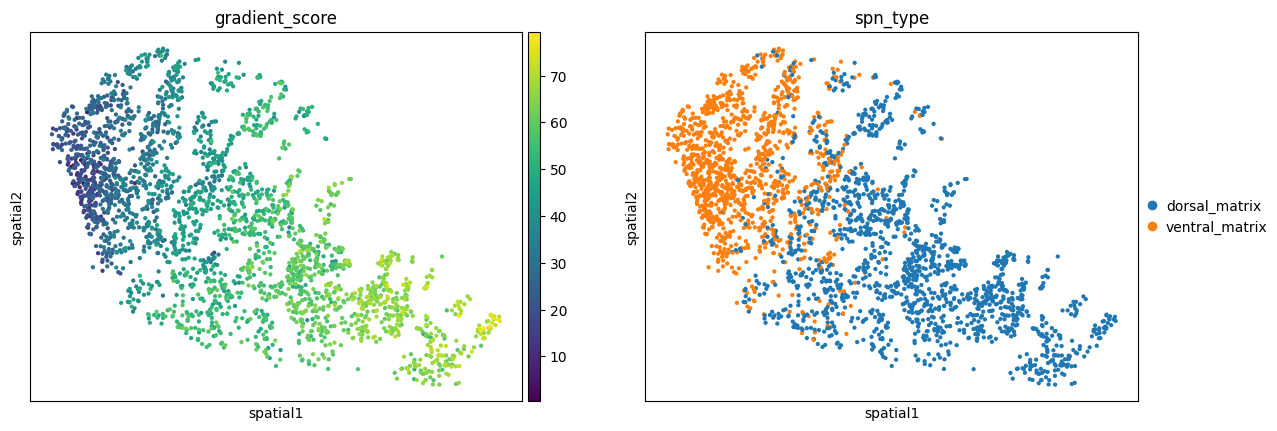

... storing 'case_control' as categorical



Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.1110e+03 3.5510e+03 6.3000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2670e+03 5.4300e+03 1.5000e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.0050e+03 5.9330e+03 1.0700e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25           0.0         s5   
UMBEB23073        UMBEB23073  2025-03-11           0.0        s12   
UMBEB23033        UMBEB23033  2025-03-18           0.0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_443938/1829431653.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']
... storing 'case_control' as categorical


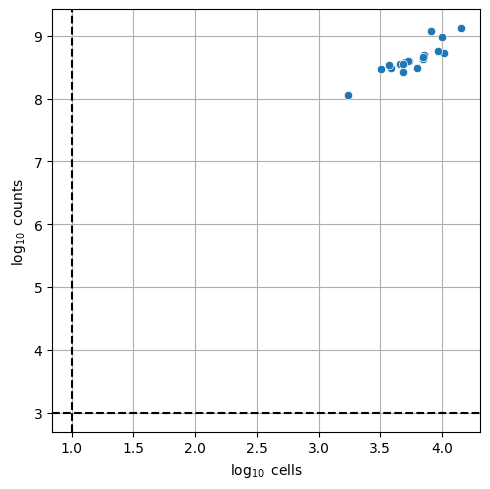

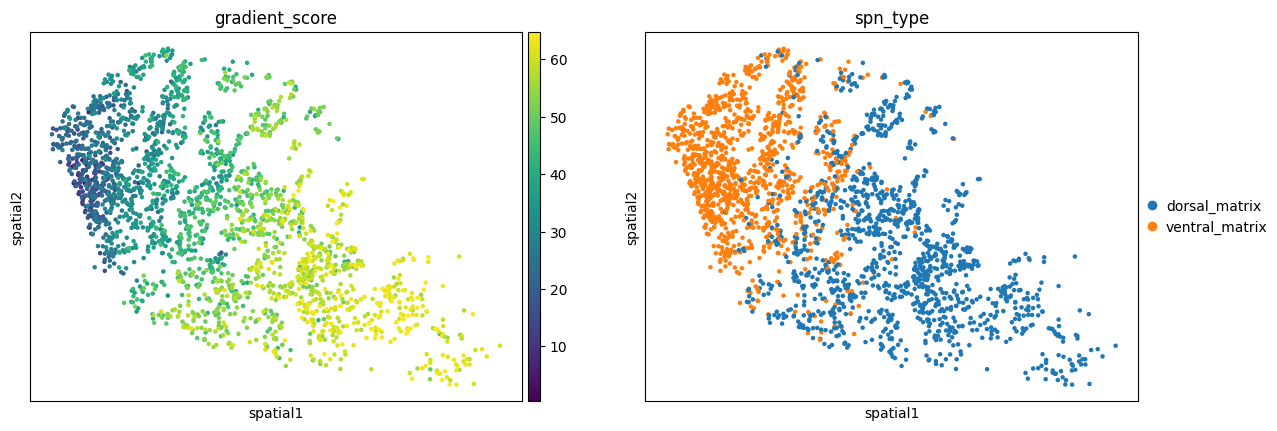

... storing 'case_control' as categorical



Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.305e+03 8.962e+03 3.570e+02 ... 0.000e+00 1.000e+00 0.000e+00]
 [1.252e+03 3.902e+03 9.900e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.207e+03 5.153e+03 1.090e+02 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [1.024e+03 3.176e+03 5.700e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.060e+03 4.874e+03 1.390e+02 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.005e+03 5.933e+03 1.070e+02 ... 0.000e+00 0.000e+00 0.000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25           0.0         s5   
UMBEB23073        UMBEB23073  2025-03-11           0.0        s12   
UMBEB23033        UMBEB23033  2025-03-18           0.0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group                                      

/tmp/ipykernel_443938/1829431653.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']
... storing 'case_control' as categorical


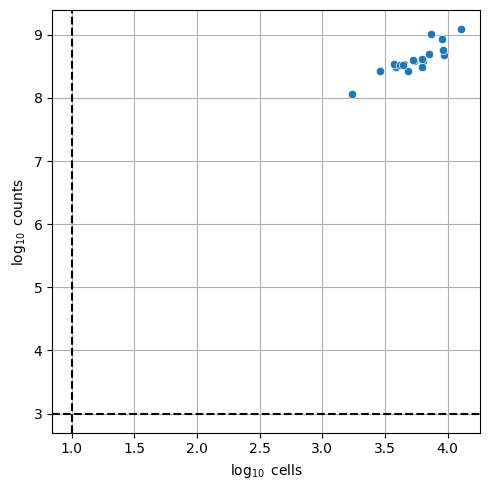

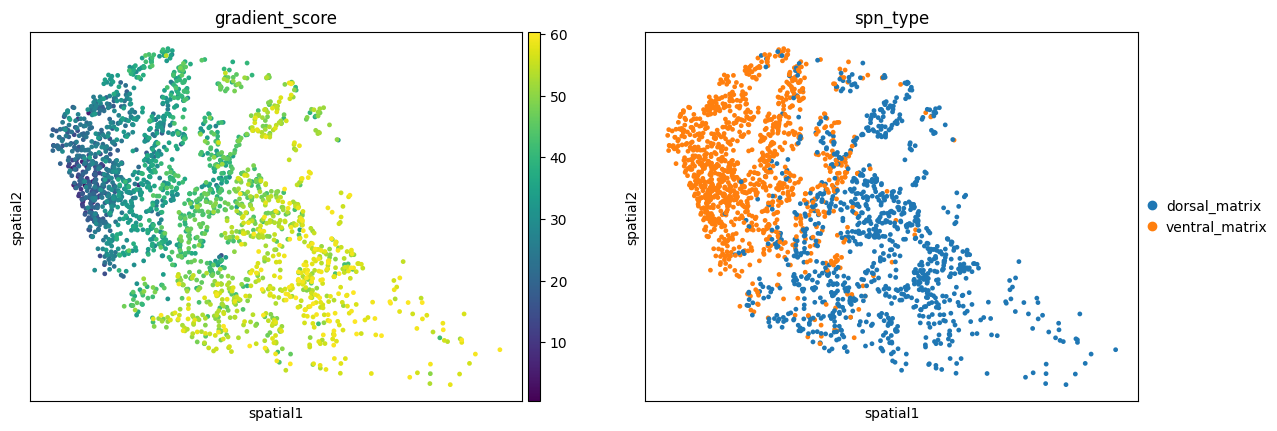

... storing 'case_control' as categorical



Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[2.922e+03 7.870e+03 3.190e+02 ... 0.000e+00 1.000e+00 0.000e+00]
 [1.109e+03 3.479e+03 9.000e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.207e+03 5.153e+03 1.090e+02 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [9.120e+02 2.849e+03 5.100e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.862e+03 4.316e+03 1.290e+02 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.005e+03 5.933e+03 1.070e+02 ... 0.000e+00 0.000e+00 0.000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25           0.0         s5   
UMBEB23073        UMBEB23073  2025-03-11           0.0        s12   
UMBEB23033        UMBEB23033  2025-03-18           0.0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group                                      

/tmp/ipykernel_443938/1829431653.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']
... storing 'case_control' as categorical


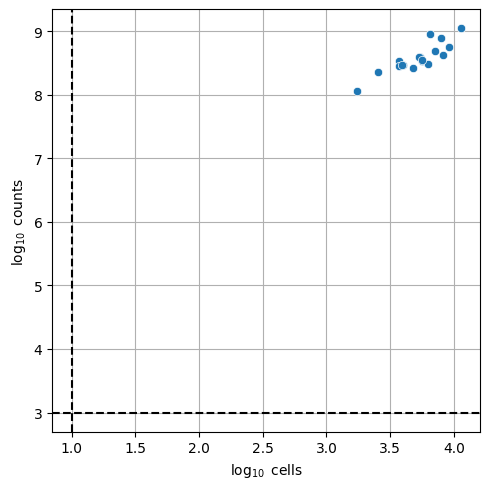

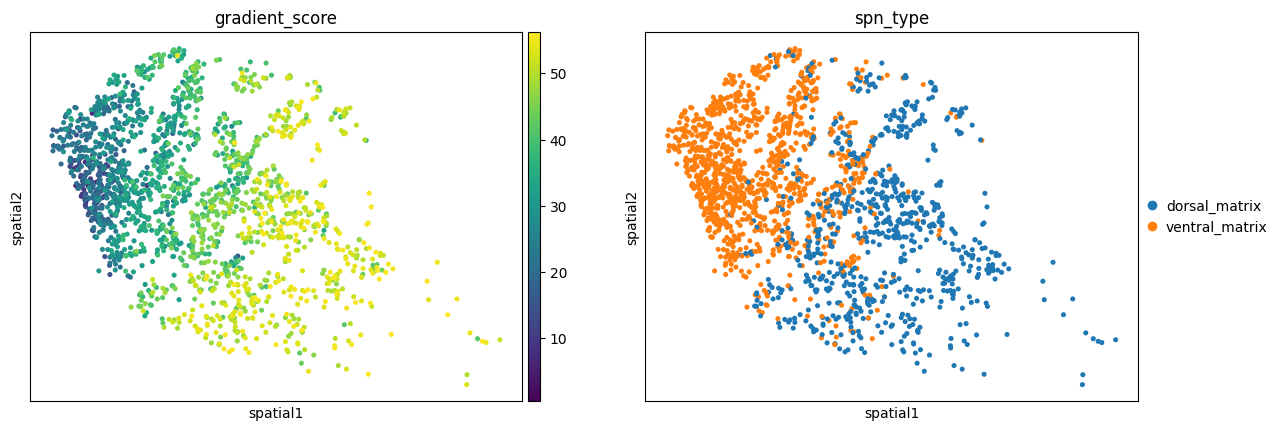

... storing 'case_control' as categorical



Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[2593. 6777.  275. ...    0.    0.    0.]
 [ 996. 3087.   81. ...    0.    0.    0.]
 [2207. 5153.  109. ...    0.    0.    0.]
 ...
 [ 817. 2510.   43. ...    0.    0.    0.]
 [1626. 3759.  113. ...    0.    0.    0.]
 [2005. 5933.  107. ...    0.    0.    0.]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25           0.0         s5   
UMBEB23073        UMBEB23073  2025-03-11           0.0        s12   
UMBEB23033        UMBEB23033  2025-03-18           0.0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group                                                            
PT13935            Subpallium GABA                                    1.0   
UMBEB23073         Subpallium GABA          

/tmp/ipykernel_443938/1829431653.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']
... storing 'case_control' as categorical


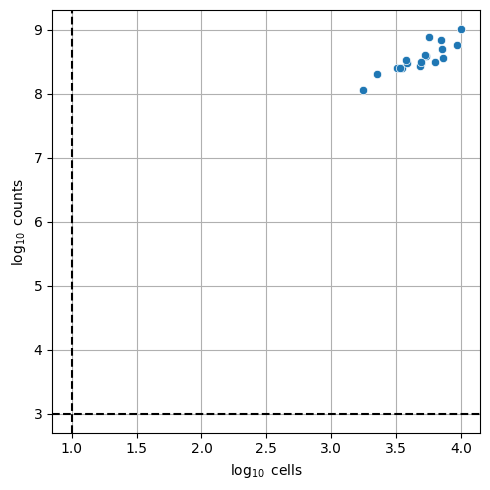

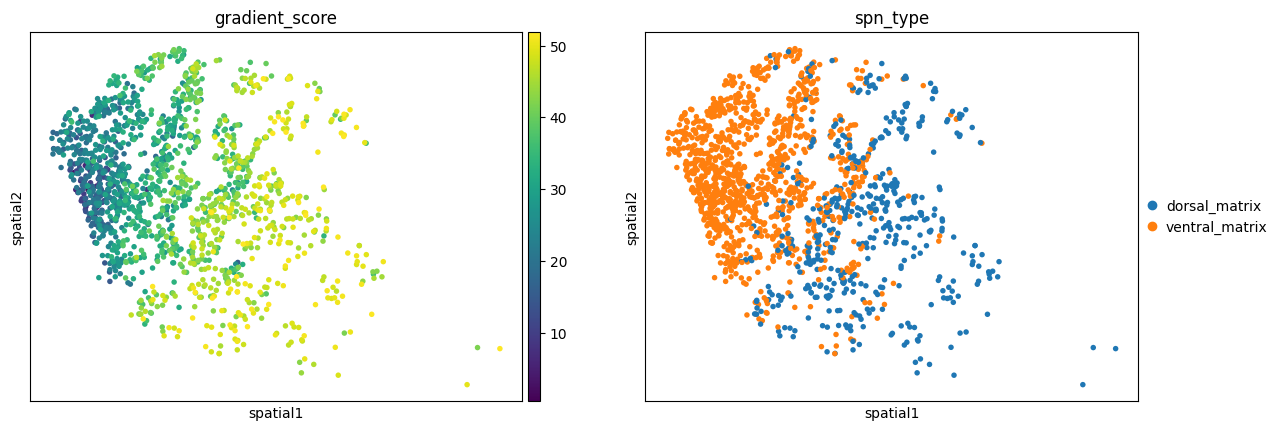

... storing 'case_control' as categorical



Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[2271. 5750.  240. ...    0.    0.    0.]
 [ 850. 2649.   70. ...    0.    0.    0.]
 [2207. 5153.  109. ...    0.    0.    0.]
 ...
 [ 721. 2144.   39. ...    0.    0.    0.]
 [1398. 3210.   91. ...    0.    0.    0.]
 [2005. 5933.  107. ...    0.    0.    0.]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25           0.0         s5   
UMBEB23073        UMBEB23073  2025-03-11           0.0        s12   
UMBEB23033        UMBEB23033  2025-03-18           0.0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group                                                            
PT13935            Subpallium GABA                                    1.0   
UMBEB23073         Subpallium GABA          

/tmp/ipykernel_443938/1829431653.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']
... storing 'case_control' as categorical


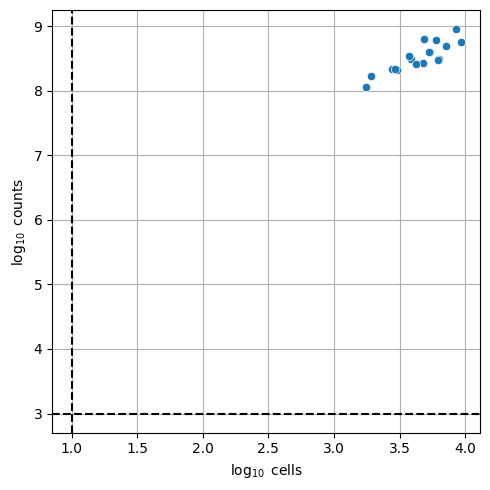

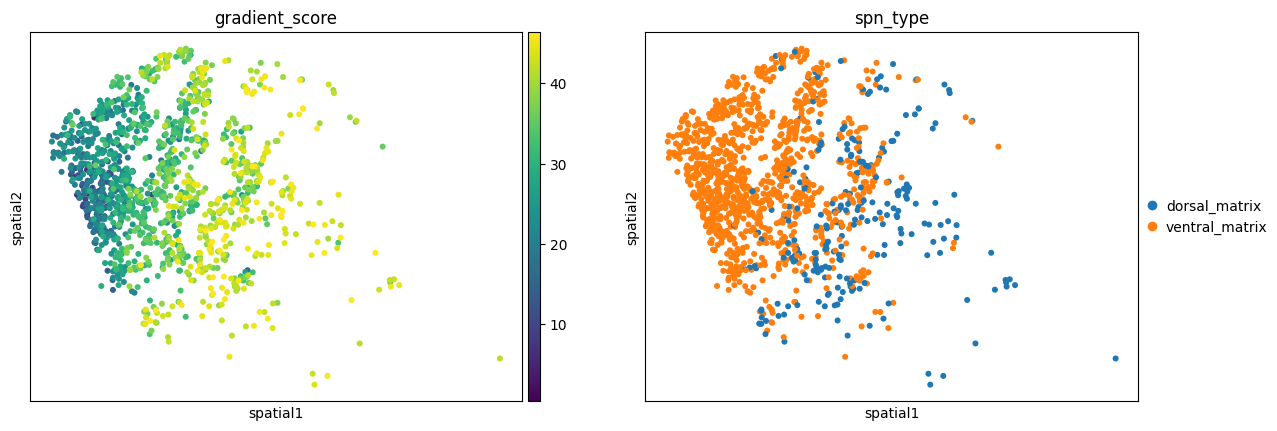

... storing 'case_control' as categorical



Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[1899. 4556.  194. ...    0.    0.    0.]
 [ 712. 2185.   61. ...    0.    0.    0.]
 [2207. 5153.  109. ...    0.    0.    0.]
 ...
 [ 614. 1755.   34. ...    0.    0.    0.]
 [1184. 2653.   72. ...    0.    0.    0.]
 [2005. 5933.  107. ...    0.    0.    0.]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25           0.0         s5   
UMBEB23073        UMBEB23073  2025-03-11           0.0        s12   
UMBEB23033        UMBEB23033  2025-03-18           0.0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group                                                            
PT13935            Subpallium GABA                                    1.0   
UMBEB23073         Subpallium GABA          

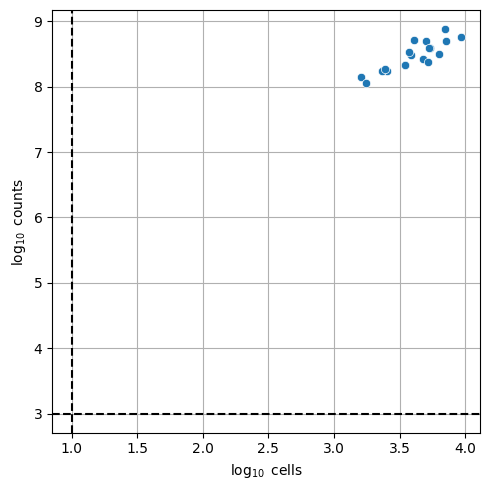

In [35]:
for pct in DEPLETION_PERCENTS:
    print("\n\n", pct)

    save_folder = os.path.join(adata_to_create_depleyed_versions_folder, f"depleted_{pct}_dorsal_matrix",)
    save_path_h5ad = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix.h5ad")
    save_path_pseudobulked = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix_pseudobulked.h5ad")
    save_path_qs = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix.qs")
    os.makedirs(save_folder, exist_ok=True)

    # if (os.path.exists(save_path_h5ad)) & (os.path.exists(save_path_qs)):
    #     print(f"\tFiles already exist, skipping...")
    #     continue

    # take obs
    obs = adata.obs.copy()
    obs_grad = df_grad.copy()
    obs = obs.merge(
        obs_grad,
        left_index=True,
        right_index=True,
        how="left", 
        validate="one_to_one"
    )
     
    # Get healthy cells (keep all)
    healthy_mask = obs[CONTRAST_VARIABLE] != CONTRAST_VARIABLE_DISEASED
    
    # Get diseased cells
    diseased_mask = obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED
    diseased_obs = obs[diseased_mask].copy()
    
    # For each diseased sample, mark cells to keep
    cells_to_keep_mask = healthy_mask.copy()  # Start with all healthy cells
    
    for sample_id in diseased_obs[DONOR_ID_VARIABLE].unique():
        # Get cells from this sample
        sample_mask = (diseased_obs[DONOR_ID_VARIABLE] == sample_id)
        sample_cells = diseased_obs[sample_mask]
        
        # Calculate how many to keep
        n_cells = len(sample_cells)
        n_cells_to_keep = int(n_cells * (1 - float(pct)))
        
        # Sort by gradient score and get bottom cells to keep (remove the most dorsal)
        sorted_cells = sample_cells.sort_values('gradient_score')
        cells_to_keep_ids = sorted_cells.index[:n_cells_to_keep]   # Keeps LOWEST scores
        
        # Mark these cells to keep
        cells_to_keep_mask[cells_to_keep_ids] = True
    
    # Single subset operation on backed adata
    adata_pert_tmp = adata[cells_to_keep_mask]

    # Save scores
    adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']

    # at the end of each lopp chekc one sample
    sample_id = "MS913848" #adata_pert_tmp.obs[adata_pert_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED][DONOR_ID_VARIABLE].unique()[0]
    adata_s = adata_pert_tmp[adata_pert_tmp.obs[DONOR_ID_VARIABLE] == sample_id].to_memory().copy()
    adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])
    del adata_s


    # Save the subsetted adata
    adata_pert_tmp.write_h5ad(save_path_h5ad)

    ########################

    # CONVERT TO QS

    # print("\tSaving files for R coversion...")
    # preprocessing.save_files_for_R_conversion(adata_pert_tmp, QS_TMP_FOLDER)
    # print("\tBuilding R obj...")
    # preprocessing.build_qs_from_python_files(
    #     QS_TMP_FOLDER, saving_path=save_path_qs, 
    #     contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_VARIABLE_HEALTHY)

    #########################

    # SAVE PSEUDOBULK
    adata_pb_all = DEG.pseudobulk(adata_pert_tmp, DONOR_ID_VARIABLE, COV_FOR_PSEUDOBULK, GROUP_DEG_COL, COVARIATES_FOR_DEG=COVARIATES_FOR_DEG, INTERESTING_COV=INTERESTING_COV,
            MIN_CELLS_PER_PSUDOCELL=MIN_CELLS_PER_PSUDOCELL,MIN_COUNTS_PER_PSEUDOCELL=MIN_COUNTS_PER_PSEUDOCELL, filter_genes=True, layer=None,
            MIN_COUNTS=MIN_COUNTS,LARGE_N=LARGE_N, MIN_TOTAL_COUNTS=MIN_TOTAL_COUNTS, MIN_PROP_BY_EXPR=MIN_PROP_BY_EXPR,MIN_PROP_BY_PROP=MIN_PROP_BY_PROP,MIN_SMPLS=MIN_SMPLS, )
    adata_pb_all.write_h5ad(save_path_pseudobulked)
    
    del adata_pert_tmp, adata_pb_all
    gc.collect()

    #break

print("Done")

# Verify dorsal.gradient

In [29]:
# adata_s = adata[adata.obs.donor_id == "PT13935"].to_memory().copy()
# adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
# obs_grad = adata.obs[["gradient_score"]].copy()
# adata_s.obs = adata_s.obs.merge(
#     obs_grad,
#     left_index=True,
#     right_index=True,
#     how="left", 
#     validate="one_to_one"
# )
# sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])